# LEGO GINN Model: Mesh Extraction, Visualization, and Latent Space Analysis

This notebook demonstrates how to load a trained GINN model checkpoint for the LEGO 1xN dataset, extract and visualize shapes, analyze mesh connectivity, and perform latent space optimization.

**Outline:**
1. Import Required Libraries
2. Load Model Checkpoint and Configuration for LEGO Dataset
3. Sample Latent Vectors for LEGO Shapes
4. Extract and Visualize Meshes for LEGO Latents
5. Compare Mesh Connectivity and Statistics
6. Latent Space Grid Mapping for LEGO
7. Latent Space Optimization for LEGO (e.g., Target Volume)
8. Visualize Optimization Results for LEGO


In [71]:
# 1. Import Required Libraries
import sys
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
import k3d
from tqdm import tqdm
import trimesh
from util.checkpointing import load_yaml_and_drop_keys
from util.misc import get_model
from models.net_w_partials import NetWithPartials
from train.train_utils.latent_sampler import LatentSampler
from util.visualization.utils_mesh import get_watertight_mesh_for_latent


## Diagnostics: Bounds per Brick Type

**CRITICAL**: Different LEGO brick types have DIFFERENT bounds!
- 1x2 brick: x spans ~[-1, 1]
- 1x4 brick: x spans ~[-2, 2]

If you use 1x2's bounds to extract a 1x4 mesh, **half the brick will be clipped**.
This cell creates all problems and prints their bounds for verification.

In [72]:
# DIAGNOSTIC: Verify bounds for each brick type
# This cell creates problems for each configured brick type and prints their bounds

from util.misc import get_problem
try:
    from util.misc import resolve_problem_config
except ImportError:
    # Fallback if kernel has cached util.misc from before resolve_problem_config was added
    def resolve_problem_config(config):
        """Return (prob_cfg, problem_sampling_kwargs) with ${vars.xxx} replaced by LEGO defaults."""
        prob_cfg = dict(config.get('problem', {'problem_str': 'lego_1xN', 'n_studs': 2}))
        if isinstance(prob_cfg.get('problem_str'), str) and prob_cfg['problem_str'].startswith('${'):
            prob_cfg['problem_str'] = 'lego_1xN'
        sampling = dict(config.get('problem_sampling', {'nx': 3}))
        defaults = {'nx': 3, 'n_points_surface': 20000, 'n_points_domain': 2048,
                   'n_points_envelope': 8192, 'n_points_interfaces': 4096, 'n_points_normals': 4096}
        for k in list(sampling.keys()):
            v = sampling[k]
            if isinstance(v, str) and '${' in v:
                sampling[k] = defaults.get(k, 3)
            elif isinstance(v, str):
                try: sampling[k] = int(v)
                except (ValueError, TypeError): sampling[k] = defaults.get(k, 3)
        return prob_cfg, sampling

def get_all_problem_bounds(config):
    """Create all problems and return a dict mapping (n, ny, h) -> bounds"""
    problem_bounds = {}

    # Coerce in case YAML vars are unresolved (e.g. '${vars.n_studs_values}')
    raw_n = config.get('n_studs_values', [2])
    n_studs_values = [2] if isinstance(raw_n, str) else [int(x) for x in raw_n if isinstance(x, (int, float)) or (isinstance(x, str) and x.isdigit())]
    if not n_studs_values:
        n_studs_values = [2]
    raw_ny = config.get('n_studs_y_values', [1])
    n_studs_y_values = [1] if isinstance(raw_ny, str) else [int(x) for x in raw_ny if isinstance(x, (int, float)) or (isinstance(x, str) and x.isdigit())]
    if not n_studs_y_values:
        n_studs_y_values = [1]
    raw_h = config.get('height_values', [1.0])
    if isinstance(raw_h, str):
        height_values = [1.0]
    else:
        height_values = []
        for x in raw_h:
            try: height_values.append(float(x))
            except (TypeError, ValueError): pass
    if not height_values:
        height_values = [1.0]

    condition_on_n_studs = config.get('condition_on_n_studs', False)
    condition_on_n_studs_y = config.get('condition_on_n_studs_y', False)
    condition_on_height = config.get('condition_on_height', False)

    base_problem_cfg, problem_sampling = resolve_problem_config(config)
    
    for n in n_studs_values:
        for ny in n_studs_y_values:
            for h in height_values:
                prob_cfg = {**base_problem_cfg, 'n_studs': n, 'height_scale': h}
                if ny != 1:
                    prob_cfg['n_studs_y'] = ny
                else:
                    prob_cfg['n_studs_y'] = None
                    
                try:
                    prob = get_problem(problem_config=prob_cfg, **problem_sampling)
                    key_label = f"1x{n}" if ny == 1 else f"{n}x{ny}"
                    if h != 1.0:
                        key_label += f" h={h}"
                    problem_bounds[key_label] = prob.bounds.cpu()
                except Exception as e:
                    print(f"Failed to create problem n={n}, ny={ny}, h={h}: {e}")
    
    return problem_bounds

# Ensure config is defined (run checkpoint cell first, or we load from YAML)
try:
    _ = config
except NameError:
    config = None
if config is None:
    config = globals().get('config')
if config is None:
    try:
        from util.checkpointing import load_yaml_and_drop_keys
        config = load_yaml_and_drop_keys('../configs/GINN/lego_1xN_wire.yml', keys_to_drop=[])
        print('Loaded config from ../configs/GINN/lego_1xN_wire.yml')
    except Exception as e:
        config = {}
        print('No config in globals; YAML load failed:', e)
if isinstance(config, dict) and config:
    all_bounds = get_all_problem_bounds(config)
    if all_bounds:
        bounds = list(all_bounds.values())[0]
        if torch.cuda.is_available():
            bounds = bounds.cuda()
    print("=" * 60)
    print("BOUNDS PER BRICK TYPE")
    print("=" * 60)
    if all_bounds:
        for label, b in all_bounds.items():
            print(f"\n{label}")
            print(f"  x: [{b[0,0]:.4f}, {b[0,1]:.4f}] (range: {b[0,1] - b[0,0]:.4f})")
            print(f"  y: [{b[1,0]:.4f}, {b[1,1]:.4f}] (range: {b[1,1] - b[1,0]:.4f})")
            print(f"  z: [{b[2,0]:.4f}, {b[2,1]:.4f}] (range: {b[2,1] - b[2,0]:.4f})")
    else:
        print("No problem bounds (all creations failed). Check config n_studs_values / height_values.")
    
    # Check which bounds are currently used
    if all_bounds and 'bounds' in globals():
        print("\n" + "=" * 60)
        print("CURRENT 'bounds' VARIABLE:")
        print("=" * 60)
        print(f"  x: [{bounds[0,0]:.4f}, {bounds[0,1]:.4f}]")
        print(f"  y: [{bounds[1,0]:.4f}, {bounds[1,1]:.4f}]")
        print(f"  z: [{bounds[2,0]:.4f}, {bounds[2,1]:.4f}]")
        print("\n⚠️  WARNING: If this doesn't match the brick type you're visualizing,")
        print("   the mesh will be INCORRECTLY CLIPPED or DISTORTED!")
else:
    print("Config not loaded. Run earlier cells first.")

Created LEGO 1x2 problem (height_scale=1.00) [no_studs=cuboid only]:
  Bounds: [[-0.987500011920929, 0.987500011920929], [-0.48750001192092896, 0.48750001192092896], [-0.6000000238418579, 0.6000000238418579]]
  Stud centers: 0 studs
  Points: 8192 far_outside, 16384 outside, 8192 around_if, 4096 inside, 0 interface, 6 walls
BOUNDS PER BRICK TYPE

1x2
  x: [-0.9875, 0.9875] (range: 1.9750)
  y: [-0.4875, 0.4875] (range: 0.9750)
  z: [-0.6000, 0.6000] (range: 1.2000)

CURRENT 'bounds' VARIABLE:
  x: [-0.9875, 0.9875]
  y: [-0.4875, 0.4875]
  z: [-0.6000, 0.6000]

⚠️  WARNING: If this doesn't match the brick type you're visualizing,
   the mesh will be INCORRECTLY CLIPPED or DISTORTED!


In [73]:
# Authoritative checkpoint loader - loads the checkpoint dict and extracts config/model args
import glob, os, torch
# Look for latest checkpoint under ../checkpoints/cond_wire/**
ckpt_candidates = sorted(glob.glob('../checkpoints/cond_wire/**/*-model.pt', recursive=True), key=os.path.getmtime)
if len(ckpt_candidates) == 0:
    print('No cond_wire checkpoints found under ../checkpoints/cond_wire; falling back to YAML only if necessary')
    ckpt = None
else:
    ckpt_path = ckpt_candidates[-1]
    print('Loading checkpoint:', ckpt_path)
    ckpt = torch.load(ckpt_path, map_location='cpu')
    print('ckpt keys:', list(ckpt.keys()))
    # Prefer ckpt['config'] if present
    cfg = ckpt.get('config', None)
    if cfg is None:
        # some checkpoints store config under other keys, try 'model' then 'cfg' fallbacks
        cfg = ckpt.get('model', {}).get('config', None) if isinstance(ckpt.get('model', None), dict) else None
    if cfg is None:
        print('Warning: config not found inside checkpoint. Will allow later YAML fallback if needed.')
        model_args = None
    else:
        # Extract model args from authoritative config inside checkpoint
        if isinstance(cfg, dict):
            model_args = cfg.get('model', cfg.get('model_args', None)) or cfg.get('model_args', {})
        else:
            model_args = None
    print('Extracted model_args keys:', list(model_args.keys()) if isinstance(model_args, dict) else model_args)

Loading checkpoint: ../checkpoints/cond_wire\2026_01_27__21_58_20-bnsrxi2p\2026_01_27__21_58_20-bnsrxi2p-model.pt
ckpt keys: ['state_dict', 'init_params']
Extracted model_args keys: None


C:\Users\chukw\AppData\Local\Temp\ipykernel_57936\3050226548.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location='cpu')


## Load Model Checkpoint and Configuration for LEGO Dataset

We load the latest LEGO 1xN wire model checkpoint and its configuration. This ensures the correct architecture and latent dimension are used.

In [74]:
# Use authoritative `model_args` from checkpoint when available; otherwise fall back to YAML
if 'model_args' in globals() and model_args is not None:
    print('Using model_args provided (checkpoint-authored).')
else:
    try:
        cfg = load_yaml_and_drop_keys('../checkpoints/GINN-config.yml', keys_to_drop=[])
        if isinstance(cfg, dict):
            if 'model' in cfg:
                model_args = cfg['model'].copy()
            elif 'model_args' in cfg:
                model_args = cfg['model_args'].copy()
            else:
                model_args = {k: v for k, v in cfg.items() if k in ['model_str','nx','nz','return_density','layers','use_legacy_gabor','w0_initial','w0','wire_scale'] }
        else:
            raise RuntimeError('Config not a dict')
        print('Loaded model_args from checkpoints/GINN-config.yml (fallback)')
    except Exception as _e:
        print('YAML fallback failed; using minimal defaults', _e)
        model_args = {'model_str':'cond_wire', 'nx':3, 'nz':2, 'return_density':False, 'layers':[5,5,5,5,128,128,128,1,1,1,1], 'use_legacy_gabor':True}
print('Debug: model_args to be used for model construction:', model_args)
# Construct model directly with the authoritative model_args. Do NOT infer or remap legacy params.
try:
    model = get_model(**model_args)
except Exception as e:
    print('Error creating model with model_args; printing model_args for inspection')
    print(model_args)
    raise

# If we loaded a checkpoint dict earlier, load its weights into the freshly constructed model
if 'ckpt' in globals() and ckpt is not None:
    try:
        state = ckpt.get('model', ckpt.get('state_dict', None))
        if state is None:
            raise KeyError("No 'model' or 'state_dict' key found in checkpoint")
        model.load_state_dict(state)
        model.eval()
        setattr(model, '_weights_loaded_from_checkpoint', True)
        print('Loaded model weights from checkpoint into `model`.')
    except Exception as e:
        print('Failed to load weights from checkpoint into model:', e)
        setattr(model, '_weights_loaded_from_checkpoint', False)
else:
    setattr(model, '_weights_loaded_from_checkpoint', False)


Loaded model_args from checkpoints/GINN-config.yml (fallback)
Debug: model_args to be used for model construction: {'nx': 3, 'nz': 2, 'model_str': 'cond_wire', 'return_density': False, 'w0_initial': 18, 'w0': 1, 'wire_scale': 6, 'layers': [128, 128, 128]}
Failed to load weights from checkpoint into model: Error(s) in loading state_dict for ConditionalWIRE:
	Missing key(s) in state_dict: "net.0.freq_scale.weight", "net.0.freq_scale.bias", "net.1.freq_scale.weight", "net.1.freq_scale.bias", "net.2.freq_scale.weight", "net.2.freq_scale.bias". 
	Unexpected key(s) in state_dict: "net.0.freqs.weight", "net.0.freqs.bias", "net.0.scale.weight", "net.0.scale.bias", "net.1.freqs.weight", "net.1.freqs.bias", "net.1.scale.weight", "net.1.scale.bias", "net.2.freqs.weight", "net.2.freqs.bias", "net.2.scale.weight", "net.2.scale.bias". 


In [75]:
# Diagnostic inspection of the constructed model and parameters
print("Diagnostic: model object:", type(model))
print(model)
print('\nDiagnostic: Iterating model.net modules:')
try:
    for i, mod in enumerate(model.net):
        print(f"Module {i}: {mod.__class__.__name__}")
        print(f"  omega_0: {getattr(mod, 'omega_0', None)}")
        print(f"  scale_0: {getattr(mod, 'scale_0', None)}")
        print(f"  has freqs: {hasattr(mod, 'freqs')}")
        print(f"  has scale: {hasattr(mod, 'scale')}")
except Exception as e:
    print('Error iterating model.net:', e)

print('\nDiagnostic: model.named_parameters() sample:')
try:
    names = [n for n, p in model.named_parameters()]
    print('\n'.join(names[:50]))
except Exception as e:
    print('Error listing named_parameters:', e)

print('\nDiagnostic: Check for netp in globals')
if 'netp' in globals():
    try:
        print('netp exists: NetWithPartials instance? ->', type(netp))
        print('Sample param keys from netp.params:')
        print('\n'.join(list(netp.params.keys())[:200]))
    except Exception as e:
        print('Error inspecting netp:', e)
else:
    print('netp not defined in this notebook namespace')

Diagnostic: model object: <class 'models.wire.ConditionalWIRE'>
ConditionalWIRE(
  (net): Sequential(
    (0): RealGaborLayer(
      (freq_scale): Linear(in_features=5, out_features=256, bias=True)
    )
    (1): RealGaborLayer(
      (freq_scale): Linear(in_features=128, out_features=256, bias=True)
    )
    (2): RealGaborLayer(
      (freq_scale): Linear(in_features=128, out_features=256, bias=True)
    )
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)

Diagnostic: Iterating model.net modules:
Module 0: RealGaborLayer
  omega_0: 18
  scale_0: 6
  has freqs: False
  has scale: False
Module 1: RealGaborLayer
  omega_0: 1
  scale_0: 6
  has freqs: False
  has scale: False
Module 2: RealGaborLayer
  omega_0: 1
  scale_0: 6
  has freqs: False
  has scale: False
Module 3: Linear
  omega_0: None
  scale_0: None
  has freqs: False
  has scale: False

Diagnostic: model.named_parameters() sample:
net.0.freq_scale.weight
net.0.freq_scale.bias
net.1.freq_scale.weight
net.1.fre

In [76]:
# Debugging RealGaborLayerLegacy initialization
from models.wire import RealGaborLayerLegacy
print("Debug: Inspecting RealGaborLayerLegacy initialization")
print(f"Debug: model_args = {model_args}")
try:
    # Filter model_args to include only valid arguments for RealGaborLayerLegacy
    valid_keys = ['return_density', 'layers', 'use_legacy_gabor']  # Updated valid keys
    filtered_args = {key: model_args[key] for key in valid_keys if key in model_args}
    print(f"Debug: filtered_args = {filtered_args}")
    gabor_layer = RealGaborLayerLegacy(**filtered_args)  # Replace with actual initialization
    print("Debug: RealGaborLayerLegacy initialized successfully")
    print(f"Debug: gabor_layer.freqs = {gabor_layer.freqs}")
    print(f"Debug: gabor_layer.scale = {gabor_layer.scale}")
except Exception as e:
    print("Error during RealGaborLayerLegacy initialization:", e)

Debug: Inspecting RealGaborLayerLegacy initialization
Debug: model_args = {'nx': 3, 'nz': 2, 'model_str': 'cond_wire', 'return_density': False, 'w0_initial': 18, 'w0': 1, 'wire_scale': 6, 'layers': [5, 128, 128, 128, 1]}
Debug: filtered_args = {'return_density': False, 'layers': [5, 128, 128, 128, 1]}
Error during RealGaborLayerLegacy initialization: RealGaborLayerLegacy.__init__() got an unexpected keyword argument 'return_density'


## Sample Latent Vectors for LEGO Shapes

We generate or load latent vectors suitable for the LEGO model. These will be used to generate and analyze shapes.

In [77]:
# 3. Sample Latent Vectors for LEGO Shapes
# Ensure `config` is available (try loading from checkpoint), otherwise use sensible defaults
if 'config' not in globals():
    try:
        config = load_yaml_and_drop_keys('../checkpoints/GINN-config.yml', keys_to_drop=[])
        print("Loaded config from ../checkpoints/GINN-config.yml")
    except Exception as e:
        print("config not found, using fallback minimal config:", e)
        config = {'model': {'nz': model_args.get('nz', 2)}, 'latent_sampling': {}}
# Use LatentSampler if available, else random sampling
# Coerce latent_sampling kwargs to correct types (YAML may leave ${vars.x} unresolved)
def _safe_int(x, default=0):
    if isinstance(x, int): return x
    try: return int(x)
    except (ValueError, TypeError): return default

def _coerce_latent_sampling_kwargs(cfg):
    d = dict(cfg.get('latent_sampling', {}))
    model_nz = _safe_int(cfg.get('model', {}).get('nz', 2), 2)
    if 'nz' in d: d['nz'] = _safe_int(d['nz'], model_nz)
    if 'ginn_bsize' in d: d['ginn_bsize'] = _safe_int(d['ginn_bsize'], 4)
    if 'val_plot_grid' in d:
        grid = d['val_plot_grid']
        d['val_plot_grid'] = [_safe_int(x, 3) for x in grid] if isinstance(grid, (list, tuple)) else [3, 3]
    return d

try:
    ls_kwargs = _coerce_latent_sampling_kwargs(config)
    lat_sampler = LatentSampler(**ls_kwargs)
    z_latents = lat_sampler.val_z()
    print(f"Loaded {len(z_latents)} latent vectors from LatentSampler.")
except Exception as e:
    print("LatentSampler not available or failed, using random z. Error:", e)
    nz = _safe_int(config.get('model', {}).get('nz', globals().get('model_args', {}).get('nz', 2)), 2)
    n_shapes = 12
    z_min, z_max = 0.0, 0.1
    device = globals().get('device', torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
    z_latents = torch.rand(n_shapes, nz, device=device) * (z_max - z_min) + z_min
    print(f"Generated {n_shapes} random latent vectors (nz={nz}).")
print(f"Sample z: {z_latents[:2]}")

Loaded 9 latent vectors from LatentSampler.
Sample z: tensor([[0.0000, 0.0000],
        [0.0000, 0.0500]])


## Extract and Visualize Meshes for LEGO Latents

For each sampled latent vector, extract the corresponding mesh using marching cubes and visualize the shapes using k3d.

In [78]:
# Helper: Get correct bounds for a latent vector based on its conditioning
# This is CRITICAL for correct mesh extraction when using multiple brick types

def get_bounds_for_latent(z, config, device):
    """
    Given a latent z that may include conditioning dimensions,
    return the correct bounds for mesh extraction.
    
    Args:
        z: latent vector [nz] which may include conditioning dims
        config: the full config dict
        device: torch device
    
    Returns:
        bounds: [3, 2] tensor with correct bounds for this brick type
    """
    from util.misc import get_problem
    try:
        from util.misc import resolve_problem_config
    except ImportError:
        def resolve_problem_config(config):
            prob_cfg = dict(config.get('problem', {'problem_str': 'lego_1xN', 'n_studs': 2}))
            if isinstance(prob_cfg.get('problem_str'), str) and prob_cfg['problem_str'].startswith('${'):
                prob_cfg['problem_str'] = 'lego_1xN'
            sampling = dict(config.get('problem_sampling', {'nx': 3}))
            defaults = {'nx': 3, 'n_points_surface': 20000, 'n_points_domain': 2048, 'n_points_envelope': 8192, 'n_points_interfaces': 4096, 'n_points_normals': 4096}
            for k in list(sampling.keys()):
                v = sampling[k]
                if isinstance(v, str) and '${' in v: sampling[k] = defaults.get(k, 3)
                elif isinstance(v, str):
                    try: sampling[k] = int(v)
                    except (ValueError, TypeError): sampling[k] = defaults.get(k, 3)
            return prob_cfg, sampling

    nz_base = 2  # Base latent dims
    full_nz = config.get('model', {}).get('nz', 2)
    if isinstance(full_nz, str):
        full_nz = 2  # e.g. unresolved ${vars.nz}
    else:
        try:
            full_nz = int(full_nz)
        except (TypeError, ValueError):
            full_nz = 2

    # If no conditioning, use default problem
    if full_nz <= nz_base:
        prob_cfg, sampling = resolve_problem_config(config)
        prob = get_problem(problem_config=prob_cfg, **sampling)
        return prob.bounds.to(device)
    
    # Extract conditioning values from z
    n_studs_values = list(config.get('n_studs_values', [2]))
    n_studs_y_values = list(config.get('n_studs_y_values', [1]))
    height_values = list(config.get('height_values', [1.0]))
    
    condition_on_n_studs = config.get('condition_on_n_studs', False)
    condition_on_n_studs_y = config.get('condition_on_n_studs_y', False)
    condition_on_height = config.get('condition_on_height', False)
    
    # Decode conditioning from z
    cond_idx = nz_base
    n_studs = n_studs_values[0]  # default
    n_studs_y = 1
    height_scale = 1.0
    
    if condition_on_n_studs and z.shape[0] > cond_idx:
        # Normalized value in [0, 1] -> actual n_studs
        n_norm = z[cond_idx].item()
        n_min, n_max = min(n_studs_values), max(n_studs_values)
        n_studs = int(round(n_norm * (n_max - n_min) + n_min))
        n_studs = max(n_min, min(n_max, n_studs))  # clamp
        cond_idx += 1
    
    if condition_on_n_studs_y and z.shape[0] > cond_idx:
        ny_norm = z[cond_idx].item()
        ny_min, ny_max = min(n_studs_y_values), max(n_studs_y_values)
        n_studs_y = int(round(ny_norm * (ny_max - ny_min) + ny_min))
        n_studs_y = max(ny_min, min(ny_max, n_studs_y))
        cond_idx += 1
    
    if condition_on_height and z.shape[0] > cond_idx:
        h_norm = z[cond_idx].item()
        h_min, h_max = min(height_values), max(height_values)
        height_scale = h_norm * (h_max - h_min) + h_min
        height_scale = max(h_min, min(h_max, height_scale))
    
# Create problem with these params
    base_prob_cfg, sampling = resolve_problem_config(config)
    prob_cfg = {**base_prob_cfg, 'n_studs': n_studs, 'height_scale': height_scale}
    if n_studs_y != 1:
        prob_cfg['n_studs_y'] = n_studs_y
    else:
        prob_cfg['n_studs_y'] = None

    prob = get_problem(problem_config=prob_cfg, **sampling)
    return prob.bounds.to(device)

print("Helper function 'get_bounds_for_latent' defined.")
print("Use this to get correct bounds when extracting meshes for conditioned models.")

Helper function 'get_bounds_for_latent' defined.
Use this to get correct bounds when extracting meshes for conditioned models.


## Diagnostics: Sign Convention (nf_is_density)

The SDF sign convention is:
- **SDF < 0**: inside the shape (material)
- **SDF > 0**: outside the shape (air)

When `nf_is_density=False`, the network outputs SDF values directly.

**Potential issue in `preprocess_for_watertight()`**: The function does `vals * -1` which inverts the SDF. This is later compensated by face-flipping, but can cause issues if not handled correctly.

In [79]:
# DIAGNOSTIC: Verify SDF sign convention at specific points
# This tests that the network outputs correct SDF values

def diagnose_sdf_sign(netp, z, bounds, device):
    """
    Test SDF values at known locations to verify sign convention.
    
    For a LEGO brick centered at origin:
    - Point at origin (0,0,0) should be INSIDE → SDF < 0
    - Point far outside (e.g., 10,10,10) should be OUTSIDE → SDF > 0
    """
    from util.model_utils import tensor_product_xz
    
    # Test points
    origin = torch.tensor([[0., 0., 0.]], device=device)
    far_outside = torch.tensor([[10., 10., 10.]], device=device)
    corner = bounds[:, 1].unsqueeze(0) * 0.9  # just inside max bounds
    
    with torch.no_grad():
        z_unsq = z.unsqueeze(0) if z.dim() == 1 else z
        
        # Evaluate at each point
        x_o, z_o = tensor_product_xz(origin, z_unsq)
        sdf_origin = netp.f_(netp.params, x_o, z_o).item()
        
        x_f, z_f = tensor_product_xz(far_outside, z_unsq)
        sdf_far = netp.f_(netp.params, x_f, z_f).item()
        
        x_c, z_c = tensor_product_xz(corner, z_unsq)
        sdf_corner = netp.f_(netp.params, x_c, z_c).item()
    
    print("=" * 60)
    print("SDF SIGN CONVENTION CHECK")
    print("=" * 60)
    print(f"Point at origin (0,0,0):    SDF = {sdf_origin:+.4f}  → {'INSIDE ✓' if sdf_origin < 0 else 'OUTSIDE ✗ (expected inside)'}")
    print(f"Point far outside (10,10,10): SDF = {sdf_far:+.4f}  → {'OUTSIDE ✓' if sdf_far > 0 else 'INSIDE ✗ (expected outside)'}")
    print(f"Point near corner:          SDF = {sdf_corner:+.4f}  → {'likely boundary region'}")
    
    nf_is_density = config.get('nf_is_density', False) if isinstance(config, dict) else False
    print(f"\nConfig nf_is_density: {nf_is_density}")
    
    if nf_is_density:
        print("Mode: DENSITY (values 0-1, high = material)")
    else:
        print("Mode: SDF (negative = inside, positive = outside)")
    
    # Check if sign convention seems correct
    if not nf_is_density and sdf_origin > 0:
        print("\n⚠️  WARNING: Origin shows POSITIVE SDF but should be INSIDE (negative)!")
        print("   This could indicate inverted SDF or incorrectly trained model.")
    elif not nf_is_density and sdf_far < 0:
        print("\n⚠️  WARNING: Far outside point shows NEGATIVE SDF but should be OUTSIDE (positive)!")
        print("   This could indicate the model doesn't generalize outside training bounds.")
    
    return sdf_origin, sdf_far, sdf_corner

# Run diagnostic if netp is available
if 'netp' in globals() and 'z_latents' in globals() and len(z_latents) > 0:
    z_test = z_latents[0].to(device)
    # Get bounds for this latent
    if isinstance(config, dict):
        test_bounds = get_bounds_for_latent(z_test, config, device)
    else:
        test_bounds = torch.tensor([[-1., 1.], [-1., 1.], [-1., 1.]], device=device)
    
    diagnose_sdf_sign(netp, z_test, test_bounds, device)
else:
    print("Run earlier cells first to load model and latents.")

Created LEGO 1x4 problem (height_scale=1.00) [no_studs=cuboid only]:
  Bounds: [[-1.9874999523162842, 1.9874999523162842], [-0.48750001192092896, 0.48750001192092896], [-0.6000000238418579, 0.6000000238418579]]
  Stud centers: 0 studs
  Points: 8192 far_outside, 16384 outside, 8192 around_if, 4096 inside, 0 interface, 6 walls
SDF SIGN CONVENTION CHECK
Point at origin (0,0,0):    SDF = +0.1434  → OUTSIDE ✗ (expected inside)
Point far outside (10,10,10): SDF = +0.1216  → OUTSIDE ✓
Point near corner:          SDF = +0.1118  → likely boundary region

Config nf_is_density: ${vars.nf_is_density}
Mode: DENSITY (values 0-1, high = material)


In [80]:
# Extract meshes with CORRECT per-latent bounds
# FIXED: Each latent may represent a different brick type, so we need different bounds

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print("Debug: device:", device)

# Recreate `netp` from `model` if needed
need_recreate = ('netp' not in globals()) or (not getattr(model, '_weights_loaded_from_checkpoint', False))
if need_recreate:
    print('Creating NetWithPartials from model (ensuring checkpoint weights are used).')
    netp = NetWithPartials.create_from_model(model, nz=model_args.get('nz', 2), nx=model_args.get('nx', 3))
    netp.params = {k: v.to(device) for k, v in netp.params.items()}
else:
    netp.params = {k: v.to(device) for k, v in netp.params.items()}

# Marching cubes resolution
mc_resolution = globals().get('mc_resolution', 128)

# Check if model uses conditioning
full_nz = model_args.get('nz', 2)
nz_base = 2
use_conditioning = full_nz > nz_base and isinstance(config, dict)

print(f"Debug: model nz={full_nz}, base nz={nz_base}, use_conditioning={use_conditioning}")
print("Debug: model_args:", model_args)
print("Debug: mc_resolution:", mc_resolution)

# Extract meshes - use per-latent bounds when conditioning is active
meshes = []
for i, z in enumerate(tqdm(z_latents, desc="Extracting meshes")):
    z = z.to(device)
    
    # Get correct bounds for this latent
    if use_conditioning:
        bounds = get_bounds_for_latent(z, config, device)
        if i == 0:
            print(f"First latent bounds: {bounds.tolist()}")
    else:
        # Fallback: use single problem bounds
        if 'bounds' not in globals() or bounds is None:
            from util.misc import get_problem
            try:
                from util.misc import resolve_problem_config
            except ImportError:
                def resolve_problem_config(config):
                    prob_cfg = dict(config.get('problem', {'problem_str': 'lego_1xN', 'n_studs': 2}))
                    if isinstance(prob_cfg.get('problem_str'), str) and prob_cfg['problem_str'].startswith('${'):
                        prob_cfg['problem_str'] = 'lego_1xN'
                    sampling = dict(config.get('problem_sampling', {'nx': 3}))
                    defaults = {'nx': 3, 'n_points_surface': 20000, 'n_points_domain': 2048, 'n_points_envelope': 8192, 'n_points_interfaces': 4096, 'n_points_normals': 4096}
                    for k in list(sampling.keys()):
                        v = sampling[k]
                        if isinstance(v, str) and '${' in v: sampling[k] = defaults.get(k, 3)
                        elif isinstance(v, str):
                            try: sampling[k] = int(v)
                            except (ValueError, TypeError): sampling[k] = defaults.get(k, 3)
                    return prob_cfg, sampling
            prob_cfg, sampling = resolve_problem_config(config)
            prob = get_problem(problem_config=prob_cfg, **sampling)
            bounds = prob.bounds.to(device)
            print(f"Using default bounds: {bounds.tolist()}")
    
    mesh = get_watertight_mesh_for_latent(
        netp.f_, netp.params, z, bounds, mc_resolution, device, 
        chunks=1, level=0, surpress_watertight=True
    )
    meshes.append(mesh)

print(f"\nExtracted {len(meshes)} meshes.")

Debug: device: cuda:0
Creating NetWithPartials from model (ensuring checkpoint weights are used).
Debug: model nz=2, base nz=2, use_conditioning=False
Debug: model_args: {'nx': 3, 'nz': 2, 'model_str': 'cond_wire', 'return_density': False, 'w0_initial': 18, 'w0': 1, 'wire_scale': 6, 'layers': [5, 128, 128, 128, 1]}
Debug: mc_resolution: 128


Extracting meshes:  33%|███▎      | 3/9 [00:00<00:01,  5.15it/s]

Extracting meshes:  56%|█████▌    | 5/9 [00:00<00:00,  7.25it/s]

Extracting meshes: 100%|██████████| 9/9 [00:01<00:00,  7.63it/s]


Extracted 9 meshes.


## Compare Mesh Connectivity and Statistics

Count connected components and vertices for each mesh. Print summary statistics (number of connected shapes, average components, average vertices).

In [81]:
# 5. Compare Mesh Connectivity and Statistics
results = []
for i, mesh in enumerate(meshes):
    verts, faces = mesh
    if len(verts) > 0 and len(faces) > 0:
        try:
            tm = trimesh.Trimesh(vertices=verts, faces=faces)
            n_components = len(tm.split(only_watertight=False))
        except Exception:
            n_components = -1
    else:
        n_components = 0
    results.append({'n_components': n_components, 'n_vertices': len(verts)})

n_connected = sum(1 for r in results if r['n_components'] == 1)
avg_components = np.mean([r['n_components'] for r in results])
avg_vertices = np.mean([r['n_vertices'] for r in results])
print(f"Connected (1 comp): {n_connected}/{len(results)}")
print(f"Avg components: {avg_components:.2f}")
print(f"Avg vertices: {avg_vertices:.0f}")
for i, r in enumerate(results):
    print(f"Shape {i+1}: {r['n_components']} components, {r['n_vertices']} vertices")

Connected (1 comp): 0/9
Avg components: 0.00
Avg vertices: 0
Shape 1: 0 components, 0 vertices
Shape 2: 0 components, 0 vertices
Shape 3: 0 components, 0 vertices
Shape 4: 0 components, 0 vertices
Shape 5: 0 components, 0 vertices
Shape 6: 0 components, 0 vertices
Shape 7: 0 components, 0 vertices
Shape 8: 0 components, 0 vertices
Shape 9: 0 components, 0 vertices


## Latent Space Grid Mapping for LEGO

Create a grid of latent vectors across the LEGO latent space, extract meshes, and visualize the grid to show how shape connectivity varies.

In [82]:
# 6. Latent Space Grid Mapping for LEGO
nz_raw = config.get('model', {}).get('nz', 2)
try:
    nz = int(nz_raw)
except (TypeError, ValueError):
    nz = 2
nz = int(nz)  # ensure integer for slice (handles float from YAML)
grid_size = 5
z_min, z_max = 0.0, 0.1
z1_vals = torch.linspace(z_min, z_max, grid_size)
z2_vals = torch.linspace(z_min, z_max, grid_size)
z_grid = []
for z1 in z1_vals:
    for z2 in z2_vals:
        z_grid.append(torch.tensor([z1.item(), z2.item()][:int(nz)], device=device))

meshes_grid = []
connectivity_grid = []
for z in tqdm(z_grid, desc="Grid meshes"):
    mesh = get_watertight_mesh_for_latent(netp.f_, netp.params, z, bounds, mc_resolution, device, chunks=1, level=0, surpress_watertight=True)
    meshes_grid.append(mesh)
    verts, faces = mesh
    if len(verts) > 0 and len(faces) > 0:
        try:
            tm = trimesh.Trimesh(vertices=verts, faces=faces)
            n_components = len(tm.split(only_watertight=False))
        except Exception:
            n_components = -1
    else:
        n_components = 0
    connectivity_grid.append(n_components)

# Visualize grid
spacing = 1.8 * (bounds[:, 1] - bounds[:, 0]).cpu().numpy()
fig = k3d.plot(height=900)
for idx, (mesh, n_comp, z) in enumerate(zip(meshes_grid, connectivity_grid, z_grid)):
    row = idx // grid_size
    col = idx % grid_size
    verts, faces = mesh
    if len(verts) > 0:
        color = 0x3498db if n_comp == 1 else 0xe74c3c
        fig += k3d.mesh(verts, faces, color=color, side='double', translation=[col*spacing[0], row*spacing[1], 0], name=f"z=[{z[0]:.2f},{z[1]:.2f}] ({n_comp} comp)")
fig.display()
print(f"Connected (1 comp): {sum(1 for c in connectivity_grid if c == 1)}/{len(connectivity_grid)}")

Grid meshes:   8%|▊         | 2/25 [00:00<00:01, 12.13it/s]

Grid meshes:  16%|█▌        | 4/25 [00:00<00:01, 12.08it/s]

Grid meshes:  24%|██▍       | 6/25 [00:00<00:01, 11.95it/s]

Grid meshes:  32%|███▏      | 8/25 [00:00<00:01, 11.97it/s]

Grid meshes:  40%|████      | 10/25 [00:00<00:01, 12.04it/s]

...

Grid meshes:  88%|████████▊ | 22/25 [00:01<00:00, 12.03it/s]

Grid meshes:  96%|█████████▌| 24/25 [00:01<00:00, 12.01it/s]

Grid meshes: 100%|██████████| 25/25 [00:02<00:00, 12.02it/s]

Output()

Connected (1 comp): 0/25


## Latent Space Optimization

Optimize a latent vector to maximize mesh connectivity or match a target property. This section demonstrates gradient-based optimization in the latent space for the LEGO GINN model.

In [83]:
# 7. Latent Space Optimization Example
from torch.optim import Adam

# Start from a random latent
z_opt = torch.randn(nz, device=device, requires_grad=True)
optimizer = Adam([z_opt], lr=0.05)

# Target: maximize number of mesh components == 1 (i.e., connected mesh)
# Note: mesh extraction and component count are not differentiable, so we use random search (no gradients).
num_steps = 30
best_z = z_opt.detach().clone()
best_score = -float('inf')
perturb_scale = 0.1  # step size for random exploration

for step in range(num_steps):
    mesh = get_watertight_mesh_for_latent(netp.f_, netp.params, z_opt, bounds, mc_resolution, device, chunks=1, level=0, surpress_watertight=True)
    verts, faces = mesh
    if len(verts) > 0 and len(faces) > 0:
        try:
            tm = trimesh.Trimesh(vertices=verts, faces=faces)
            n_components = len(tm.split(only_watertight=False))
        except Exception:
            n_components = -1
    else:
        n_components = 0
    # Reward connected mesh, penalize disconnected
    score = 1.0 if n_components == 1 else -n_components
    if score > best_score:
        best_score = score
        best_z = z_opt.detach().clone()
    # Next point: perturb from best so far (gradient-free random search)
    z_opt.data = best_z + perturb_scale * torch.randn_like(best_z, device=device)
    print(f"Step {step+1}: n_components={n_components}, score={score}")

# Visualize optimized mesh
mesh = get_watertight_mesh_for_latent(netp.f_, netp.params, best_z, bounds, mc_resolution, device, chunks=1, level=0, surpress_watertight=True)
verts, faces = mesh
if len(verts) > 0:
    fig = k3d.plot(height=600)
    fig += k3d.mesh(verts, faces, color=0x2ecc71, side='double', name='Optimized')
    fig.display()
else:
    print("No mesh generated from optimized latent.")

Step 1: n_components=0, score=0
Step 2: n_components=0, score=0
Step 3: n_components=0, score=0
Step 4: n_components=0, score=0
Step 5: n_components=0, score=0
Step 6: n_components=0, score=0
Step 7: n_components=0, score=0
Step 8: n_components=0, score=0
Step 9: n_components=0, score=0
Step 10: n_components=0, score=0
Step 11: n_components=0, score=0
Step 12: n_components=0, score=0
Step 13: n_components=0, score=0
Step 14: n_components=0, score=0
Step 15: n_components=0, score=0
Step 16: n_components=0, score=0
Step 17: n_components=0, score=0
Step 18: n_components=0, score=0
Step 19: n_components=0, score=0
Step 20: n_components=0, score=0
Step 21: n_components=0, score=0
Step 22: n_components=0, score=0
Step 23: n_components=0, score=0
Step 24: n_components=0, score=0
Step 25: n_components=0, score=0
Step 26: n_components=0, score=0
Step 27: n_components=0, score=0
Step 28: n_components=0, score=0
Step 29: n_components=0, score=0
Step 30: n_components=0, score=0
No mesh generated f

## Visualization and Summary

Summarize findings, visualize key results, and discuss the implications of latent space structure and mesh connectivity for the LEGO GINN model.

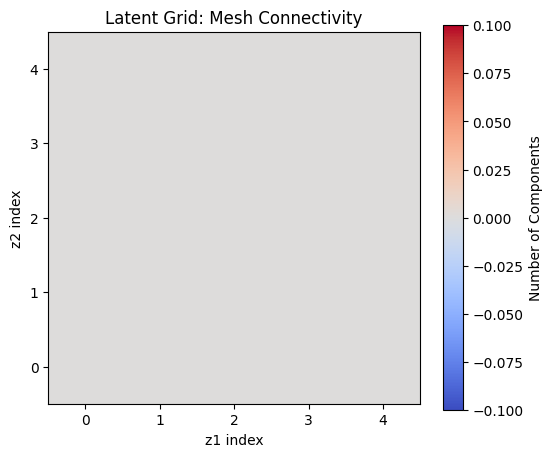

Connected meshes in grid: 0/25
Best optimized latent produced a disconnected mesh.


In [84]:
# 8. Visualization and Summary
# Show a summary plot of grid connectivity and optimized mesh
import matplotlib.pyplot as plt

# Grid connectivity heatmap
conn_arr = np.array(connectivity_grid).reshape((grid_size, grid_size))
plt.figure(figsize=(6,5))
plt.imshow(conn_arr, cmap='coolwarm', origin='lower')
plt.colorbar(label='Number of Components')
plt.title('Latent Grid: Mesh Connectivity')
plt.xlabel('z1 index')
plt.ylabel('z2 index')
plt.show()

# Print summary
n_connected = sum(1 for c in connectivity_grid if c == 1)
print(f"Connected meshes in grid: {n_connected}/{len(connectivity_grid)}")
print(f"Best optimized latent produced {'a connected mesh' if best_score == 1.0 else 'a disconnected mesh'}.")